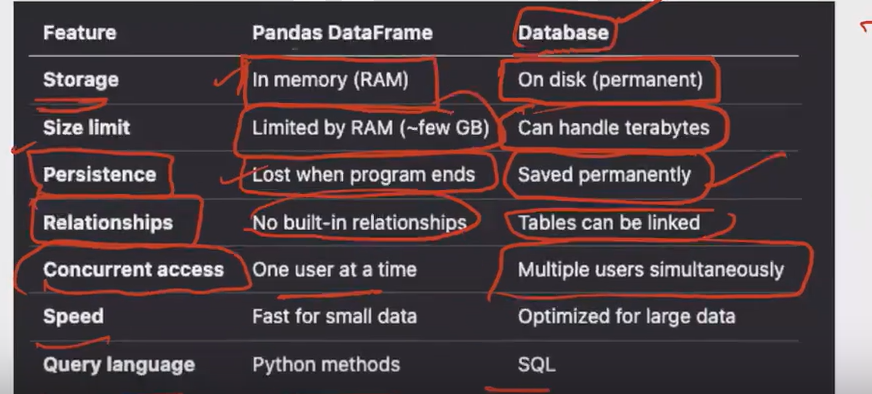

## RELATIONAL DB (Vs) NON-RELATIONAL DB

| Feature            | Relational Database (RDBMS)  | Non-Relational Database (NoSQL) |
| ------------------ | ---------------------------- | ------------------------------- |
| **Structure**      | Tables (rows & columns)      | JSON, key-value, graph, column  |
| **Schema**         | Fixed / predefined           | Dynamic / flexible              |
| **Data Format**    | Structured data              | Structured + semi/unstructured  |
| **Relationships**  | Strong (foreign keys, joins) | Weak / handled via embedding    |
| **Normalization**  | Highly normalized            | Usually denormalized            |
| **Scalability**    | Vertical scaling             | Horizontal scaling              |
| **Performance**    | Slower for huge data         | Faster for large-scale data     |
| **Transactions**   | ACID compliant               | BASE (eventual consistency)     |
| **Flexibility**    | Less flexible                | Highly flexible                 |
| **Query Language** | SQL                          | No standard (varies)            |
| **Best Use Cases** | Banking, ERP, OLTP systems   | Big data, real-time apps        |
| **Examples**       | MySQL, PostgreSQL            | MongoDB, Redis                  |


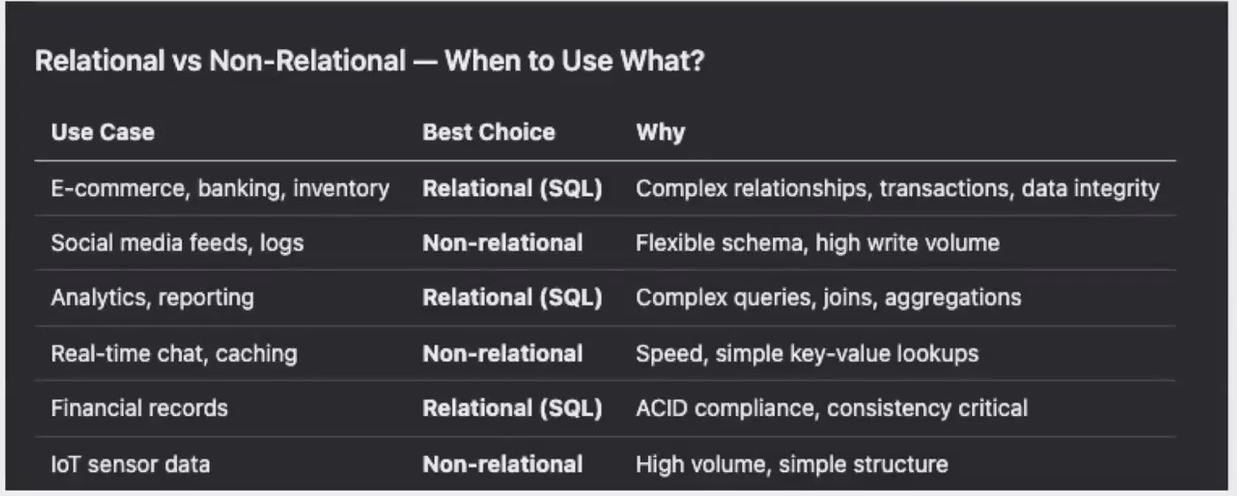

We use SQLLite library in python, to practice

We can create DB in 2 ways, 
1. one is in memory( like this will work only till the progrma runs, one the kernel restarts or closes, this will not work)
2. Next one is, creating apermanent db in my system.


In [98]:
import sqlite3
import pandas as pd
import seaborn as sb

In [8]:
#Thisis in memory database.
connection = sqlite3.connect(':memory:')
print(f"In-Memory db created:{connection}")

In-Memory db created:<sqlite3.Connection object at 0x0000023F68872020>


In [10]:
#Permanent db creation
conn = sqlite3.connect('MyDataBase.db')
print(f"My permanent db is created:{conn}")

My permanent db is created:<sqlite3.Connection object at 0x0000023F688727A0>


In [11]:
#Fot all the sql queries to run we need a cursor. In softwares,the connenction
# and cursor creation will automatically taken care by DB. but in python, the sqllite is designed in this way.

cursor = conn.cursor()
print(f"My cursor to the permanent db is created:{conn}")

My cursor to the permanent db is created:<sqlite3.Connection object at 0x0000023F688727A0>


In [16]:
cursor.execute("CREATE TABLE IF NOT EXISTS samplTbl(id INTEGER, name TEXT)")
conn.commit()
conn.close()

In [17]:
cursor.execute("SELECT * FROM  samplTbl")


ProgrammingError: Cannot operate on a closed database.

In [19]:
conn = sqlite3.connect('eCommerce.db')
cursor = conn.cursor()


In [26]:
cursor.execute("CREATE TABLE IF NOT EXISTS customer(custID INTEGER PRIMARY KEY AUTOINCREMENT,name TEXT NOT NULL \
,email TEXT UNIQUE NOT NULL,city TEXT,signUpDate DATE)")

In [27]:
cursor.execute("CREATE TABLE IF NOT EXISTS products(prodID INTEGER PRIMARY KEY AUTOINCREMENT,prodName TEXT NOT NULL \
,category TEXT,price REAL,stock INTEGER)")

In [31]:
cursor.execute("CREATE TABLE IF NOT EXISTS orders(orderID INTEGER PRIMARY KEY AUTOINCREMENT,custID INTEGER NOT NULL \
,orderdate DATE NOT NULL,totalAmt REAL DEFAULT 0, \
FOREIGN KEY(custID) REFERENCES customer(custID))")

In [82]:
#Table 4: Order Items (junction table)
cursor.execute("CREATE TABLE IF NOT EXISTS order_items (item_id INTEGER PRIMARY KEY AUTOINCREMENT, \
orderID INTEGER NOT NULL, prodID INTEGER NOT NULL, quantity INTEGER NOT NULL, price REAL NOT NULL, \
FOREIGN KEY (orderID) REFERENCES orders(orderID), FOREIGN KEY (prodID) REFERENCES products (prodID))")
#Table 5: Reviews


cursor.execute("CREATE TABLE IF NOT EXISTS reviews ( review_id INTEGER PRIMARY KEY AUTOINCREMENT, \
prodID INTEGER NOT NULL, custID INTEGER NOT NULL, rating INTEGER CHECK(rating >= 1 AND rating <= 5 ), \
review_text TEXT, review_date DATE, FOREIGN KEY (prodID) REFERENCES products (prodID), \
FOREIGN KEY (custID) REFERENCES customers(custID))")

In [116]:
conn.commit()
conn.close()
print("All tables committed and db closed")

All tables committed and db closed


In [36]:
conn = sqlite3.connect("eCommerce.db")
cursor = conn.cursor()

In [115]:
tables = ['customer','products','orders','order_items','reviews','titanicTbl']

for table in tables:
    print(f"table name: {table}")
    cursor.execute(f"select * from {table}")
    column_names = [col[0] for col in cursor.description]
    print(column_names)   # prints column headers
    rows = cursor.fetchmany()
    for row in rows:
        print(row)

table name: customer
['custID', 'name', 'email', 'city', 'signUpDate']
(1, 'Zoe', 'zoe@r.com', 'Manchester', '23-12-2018')
table name: products
['prodID', 'prodName', 'category', 'price', 'stock']
(1, 'Laptop', 'Electronics', 999.99, 15)
table name: orders
['orderID', 'custID', 'orderdate', 'totalAmt']
(1, 1, '2024-01-15', 1029.98)
table name: order_items
['item_id', 'orderID', 'prodID', 'quantity', 'price']
(1, 1, 1, 1, 999.99)
table name: reviews
['review_id', 'prodID', 'custID', 'rating', 'review_text', 'review_date']
(1, 1, 1, 5, 'Excellent laptop! Very fast.', '2824-01-18')
table name: titanicTbl
['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']
(0, 3, 'male', 22.0, 1, 0, 7.25, 'S', 'Third', 'man', 1, None, 'Southampton', 'no', 0)


In [41]:
cursor.execute("INSERT INTO customer VALUES(1, 'Zoe','zoe@r.com','Manchester','23-12-2018')")

In [110]:
conn.commit()

In [47]:
# Insert customers
customers_data = [
('Alice Johnson', 'alice@email.com', 'New York', '2023-01-15'),
('Bob Smith', 'bob@email.com', 'Chicago', '2023-02-20'),
('Carol White', 'carol@email.com', 'New York', '2023-03-10'),
('David Brown', 'david@email.com', 'Los Angeles', '2023-04-05'),
('Eve Davis', 'eve@email.com', 'Chicago', '2023-05-12')
]

conn.executemany(''' INSERT INTO customer (name ,email,city,signUpDate) VALUES 
(?,?,?,?) ''', customers_data)

In [57]:
#Insert products
products_data = [
('Laptop', 'Electronics', 999.99, 15),
('Wireless Mouse', 'Electronics', 29.99, 50),
('Office Chair', 'Furniture', 199.99, 30),
('Desk Lamp', 'Furniture', 45.99, 40),
('Notebook', 'Stationery', 5.99, 200),
('Pen Set', 'Stationery', 12.99, 150),
('Monitor', 'Electronics', 299.99, 20),
('Keyboard', 'Electronics', 79.99, 35)
 ]

cursor.executemany('''
INSERT INTO products (prodName, category, price, stock)
VALUES (?,?,?,?)''',
products_data)


In [61]:
#Insert orders
orders_data = [
(1, '2024-01-15', 1029.98),
#Alice's order
(2, '2024-01-16', 329.98),
#Bob's order
(1, '2024-01-20', 45.99),
#Alice's second order
(3, '2024-01-22', 1299.97),
#Carol's order
(4, '2024-01-25', 18.98)
#David's order
]
cursor.executemany('''
INSERT INTO orders (custID, orderdate, totalAmt)
VALUES (?, ?, ?)'''
, orders_data)

In [63]:
#Insert products
products_data = [
('Laptop', 'Electronics', 999.99, 15),
('Wireless Mouse', 'Electronics', 29.99, 50),
('Office Chair', 'Furniture', 199.99, 30),
('Desk Lamp', 'Furniture', 45.99, 401),
('Notebook', 'Stationery', 5.99, 200),
('Pen Set', 'Stationery', 12.99, 150),
('Monitor', 'Electronics', 299.99, 20),
('Keyboard', 'Electronics', 79.99, 35)
 ]
cursor.executemany('''
INSERT INTO products (prodName, category, price, stock)
VALUES (?, ?, ?, ?)'''
, products_data)

In [70]:
#Insert orders
orders_data = [
(1, '2024-01-15', 1029.98),
#Alice's order
(2, '2024-01-16', 329.98),
#Bob's order
(1, '2024-02-20', 45.99),
#Alice's second order
(3, '2024-01-22', 1299.97),
(4, '2024-01-25', 18.98)
#David's order
 ]

cursor.executemany('''
INSERT INTO orders (custID, orderdate, totalAmt)
VALUES (?, ?, ?)''',
orders_data)


In [72]:
#Insert order items
order_items_data =[
(1, 1, 1, 999.99),
(1, 2, 1, 29.99),
(2, 7, 1, 299.99),
(2, 2, 1, 29.99),
(3, 4, 1, 45.99),
(4, 1, 1, 999.99),
(4, 7, 1, 299.99),
(15, 5, 2, 5.99),
(5, 6, 1, 12.99)
]


cursor.executemany('''
INSERT INTO order_items (orderID, prodID, quantity, price)
VALUES (?, ?, ?,?)'''
, order_items_data)


In [87]:
#Insert reviews
reviews_data = [
(1, 1, 5, 'Excellent laptop! Very fast.', '2824-01-18'),
(1, 3, 4, 'Good laptop but a bit pricey.', '2024-01-25'),
(2, 1, 5, 'Best mouse I ever bought!', '2024-01-17'),
(7, 2, 4, 'Great monitor, good value.', '2024-01-19'),
(3, 1, 5, 'Very comfortable chair!', '2024-01-23'),
(4, 3, 3, 'Lamp is okay, not very bright.', '2024-01-26')
]
cursor.executemany('''
INSERT INTO reviews (prodID, custID, rating, review_text, review_date)
VALUES (?,?,?,?,?)''',
reviews_data)

## PANDAS

In [95]:
customersDF = pd.read_sql('SELECT * FROM customer',conn)
customersDF

,custID,name,email,city,signUpDate
0,1,Zoe,zoe@r.com,Manchester,23-12-2018
1,2,Alice Johnson,alice@email.com,New York,2023-01-15
2,3,Bob Smith,bob@email.com,Chicago,2023-02-20
3,4,Carol White,carol@email.com,New York,2023-03-10
4,5,David Brown,david@email.com,Los Angeles,2023-04-05
5,6,Eve Davis,eve@email.com,Chicago,2023-05-12


In [97]:
customersDF.shape

(6, 5)

In [109]:
titanicDF = sb.load_dataset('titanic')
titanicDF

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


## Creation of SQL table from DATAFRAME

This will be usefull when your input data in for m of sql tables and you want to convert into dataframes and then do pandas related operation.

In [100]:
#Creation of table.
titanicDF.to_sql('titanicTBL',conn,if_exists='replace',index=False)
print(f"created titanicTBL of rows {len(titanicDF)} from titanicDF dataframe")

created titanicTBL of rows 891 from titanicDF dataframe


In [107]:
#Verify if dtata present.
colNames = [col[0] for col in cursor.description]
print(colNames)
cursor.execute("SELECT * FROM titanicTBL")
print(cursor.fetchmany())

['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']
[(0, 3, 'male', 22.0, 1, 0, 7.25, 'S', 'Third', 'man', 1, None, 'Southampton', 'no', 0)]


### How to list all the tables present in my database

In [120]:
conn = sqlite3.connect('eCommerce.db')
cursor = conn.cursor()
#The cursor will now hold the result of the query, whcih can be fetched using fetch methods.
cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")

tables = cursor.fetchall()

for table in tables:
    print(table[0])

customer
sqlite_sequence
products
orders
order_items
reviews
titanicTBL
